In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import datetime


import sys
import os

In [2]:
# MAGIA (não mexer mt pfv)
def show_args(func):
    def wrapper(*args, **kwargs):
        arg_list = []

        # Prepare argument list
        for name, value in zip(func.__code__.co_varnames, args):
            if isinstance(value, pd.DataFrame):
                arg_list.append(f"{name}: DataFrame ({value.shape})")
            else:
                arg_list.append(f"{name}: {value}")
        for k, v in kwargs.items():
            if isinstance(v, pd.DataFrame):
                arg_list.append(f"{k}: DataFrame ({v.shape})")
            else:
                arg_list.append(f"{k}: {v}")

        #print(f"Executando <{func.__name__}>\n({'\\n'.join(arg_list)})")

        # Measure execution time
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()

        print(f"Tempo de execução: {end - start:.6f} segundos\n")
        return result
    return wrapper

In [3]:
from pathlib import Path
import pandas as pd

@show_args
def csvs_to_parquet(input_folder, output_folder):
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    for csv_file in input_path.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file, encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(csv_file, encoding="latin1")

        parquet_file = output_path / csv_file.with_suffix(".parquet").name
        df.to_parquet(parquet_file, index=False)



In [4]:
csvs_to_parquet("../data/data/refined/csvs", "../data/data/refined/parquets")

KeyboardInterrupt: 

In [ ]:
articles_raw = pd.read_parquet('../data/data/refined/parquets/article.parquet').rename(columns={
    'eid': 'art_id',
    'subtype description': 'art_subtype',
    'title': 'art_title',
    'published date': 'art_published_date',
    'cited by count': 'art_citations',
    'source id' : 'art_source',
    'aggregation type' : 'art_source_type'
})[['art_id', 'art_subtype', 'art_title', 'art_published_date', 'art_citations', 'art_source', 'art_source_type']] # B

scores_raw = pd.read_parquet('../data/data/refined/parquets/CiteScore_2024_annual_values.parquet').rename(columns={
    'Scopus Source ID' : 'art_source',
    'Title' : 'src_title',
    'Citation Count' : 'src_citation_count',
    'CiteScore' : 'src_citescore',
    'Scopus Sub-Subject Area' : 'src_subject_area',
    'Percentile' : 'src_percentile',
    'RANK' : 'src_rank',
    'Rank Out Of' : 'src_rank_count',
    'Quartile' : 'src_quartile'
})[['art_source', 'src_title', 'src_citation_count', 'src_citescore', 'src_subject_area', 'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile']]


authors_institutions_raw = pd.read_parquet('../data/data/refined/parquets/authors_institution.parquet').rename(columns={
    #eid,auid,creator,afid,dptid,organization,country,city
    'eid': 'art_id',
    'auid': 'aut_id',
    'creator': 'main_writer',
    'afid': 'ins_id',
    'dptid': 'dpt_id',
    'organization': 'ins_org',
    'country': 'ins_country',
    'city': 'ins_city'
})

institutions_raw = (pd.read_parquet('../data/data/refined/parquets/institutions.parquet').rename(columns={
        'Código Mantenedora': 'ins_maint_id',
        # 'Razão Social': 'ins_legal_name',
        # 'Município': 'ins_city',
        # 'UF': 'ins_state',
        # 'Tipo de Credenciamento': 'ins_modalidade',
        'Categoria': 'ins_category',
        # 'CI': 'ins_ci',
        # 'Ano CI': 'ins_ci_year',
        # 'CI-EaD': 'ins_ci_ead',
        # 'Ano CI-EaD': 'ins_ci_ead_year',
        # 'IGC': 'ins_igc',
        'afid': 'ins_id',
        # 'Ano IGC': 'ins_igc_year',
        'Situação da IES': 'ins_status',
        'Código IES': 'ins_code',
        'name': 'ins_name'
    })
    [['ins_maint_id', 'ins_category', 'ins_id', 'ins_status', 'ins_code', 'ins_name']]
)

#articles_authors_raw = pd.read_parquet('../data/data/refined/parquets/articles_author.parquet').rename(columns={
#    'eid': 'art_id',
#    'auid': 'aut_id',
#    'creator': 'main_writer'
#})[['art_id', 'aut_id', 'main_writer']]
#
authors_raw = pd.read_parquet('../data/data/refined/parquets/author.parquet').rename(columns={
    'auid': 'aut_id',
    'given name': 'aut_name',
    'surname': 'aut_surname',
    'indexed name': 'aut_indexed_name'
})[['aut_id', 'aut_name', 'aut_surname', 'aut_indexed_name']]

# departments_raw = pd.read_parquet('../data/data/refined/parquets/departments.parquet').rename(columns={
#     'afid' : 'ins_id',
#     'dptid': 'dpt_id',
#     'organization': 'dpt_name',
#     'country' : 'dpt_country',
#     'city' : 'dpt_city'
# })[['ins_id', 'dpt_id', 'dpt_name', 'dpt_country', 'dpt_city']]

# articles_subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/article_subject_areas.parquet').rename(columns={
#     'eid': 'art_id',
#     'subject area code': 'sub_id'
# })[['art_id', 'sub_id']] # A

subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/subject_area.parquet')
subject_areas_raw.columns = ['sub_id', 'src_subject_area', 'src_subject_macro'] # A

# articles_institutions_raw = pd.read_parquet('../data/data/refined/parquets/articles_institution.parquet').rename(columns={
#     'eid': 'art_id',
#     'afid': 'ins_id',
#     'creator': 'main_writer',
#     'country': 'ins_country'
# })[['art_id', 'ins_id', 'main_writer', 'ins_country']]




In [ ]:
articles_raw.shape

(901544, 7)

In [ ]:
main = (
articles_raw
    .merge(scores_raw, on='art_source', how='inner')
    .merge(authors_institutions_raw, on='art_id', how='inner')
    .merge(institutions_raw, on='ins_id', how='inner')
    .merge(authors_raw, on='aut_id', how='inner')
    .merge(subject_areas_raw, on='src_subject_area', how='inner')
    #.merge(authors_raw, on='aut_id', how='inner')
    #.merge(institutions_raw, on='art_id', how='inner')
    # .merge(subjects_info, on='art_id', how='inner')
    # .merge(articles_raw, on='art_source', how='inner')
)

#articles_institutions_raw['ins_id'] = articles_institutions_raw['ins_id'].astype(str)
#institutions_raw['ins_id'] = institutions_raw['ins_id'].astype(str)
#departments_raw['ins_id'] = departments_raw['ins_id'].astype(str)
#main = main.merge(departments_info, on='ins_id', how='left')


In [ ]:
institutions_raw['ins_id'].value_counts()

ins_id
60003597     31
60022378     31
60281103     21
60019608      8
60021699      8
             ..
118511108     1
118626976     1
101929885     1
106310222     1
131888906     1
Name: count, Length: 1159, dtype: int64

In [ ]:
main.head()

,art_id,art_subtype,art_title,art_published_date,art_citations,art_source,art_source_type,src_title,src_citation_count,src_citescore,...,ins_maint_id,ins_category,ins_status,ins_code,ins_name,aut_name,aut_surname,aut_indexed_name,sub_id,src_subject_macro
0,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Giliane,Belarmino,Belarmino G.,2701,MEDI
1,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Lilian Mika,Horie,Horie L.M.,2701,MEDI
2,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Priscila Campos,Sala,Sala P.C.,2701,MEDI
3,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Raquel S.,Torrinhas,Torrinhas R.S.,2701,MEDI
4,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Dan L.,Waitzberg,Waitzberg D.L.,2701,MEDI


In [ ]:
teste = main.head(6000)
#teste.to_csv('teste.csv')

In [ ]:
main.columns

Index(['art_id', 'art_subtype', 'art_title', 'art_published_date',
       'art_citations', 'art_source', 'art_source_type', 'src_title',
       'src_citation_count', 'src_citescore', 'src_subject_area',
       'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile',
       'aut_id', 'main_writer', 'ins_id', 'dpt_id', 'ins_org', 'ins_country',
       'ins_city', 'ins_maint_id', 'ins_category', 'ins_status', 'ins_code',
       'ins_name', 'aut_name', 'aut_surname', 'aut_indexed_name', 'sub_id',
       'src_subject_macro'],
      dtype='object')

In [ ]:
ranking = main[['art_id', 'art_subtype', 'art_published_date', 'src_subject_area', 'src_subject_macro', 'src_quartile', 'ins_maint_id', 'ins_name', 'ins_category', 'ins_country', 'aut_id']]
institution = main[['ins_maint_id', 'ins_name', 'ins_category', 'ins_status']].drop_duplicates(subset=['ins_maint_id'])


print(institution.shape)

(571, 4)


In [ ]:
print(institution[(institution['ins_name'] == 'Universidade Federal Fluminense')])

    ins_maint_id                         ins_name ins_category ins_status
15         15589  Universidade Federal Fluminense      Publica      Ativa


In [ ]:
institution.head()

,ins_maint_id,ins_name,ins_category,ins_status
0,15715,Universidade de São Paulo,Publica,Ativa
15,15589,Universidade Federal Fluminense,Publica,Ativa
19,14678,Universidade Federal de Santa Maria,Publica,Ativa
21,15515,Universidade Federal de Minas Gerais,Publica,Ativa
25,283,Universidade de Pernambuco,Publica,Ativa


In [ ]:
ranking.head()

,art_id,art_subtype,art_published_date,src_subject_area,src_subject_macro,src_quartile,ins_maint_id,ins_name,ins_category,ins_country,aut_id
0,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,1,15715,Universidade de São Paulo,Publica,Brazil,56862304200
1,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,1,15715,Universidade de São Paulo,Publica,Brazil,16241649700
2,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,1,15715,Universidade de São Paulo,Publica,Brazil,54400149800
3,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,1,15715,Universidade de São Paulo,Publica,Brazil,6506627898
4,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,1,15715,Universidade de São Paulo,Publica,Brazil,7006460075


In [ ]:
ranking['src_quartile'].value_counts()

src_quartile
1    2739535
2    1708417
3    1222125
4     614250
Name: count, dtype: int64

In [ ]:
#ranking2 = ranking[(ranking['src_quartile'] == 4)]

In [ ]:
#ranking2['src_quartile'].value_counts()

In [ ]:
ranking_article = ranking.loc[ranking['art_subtype'] == 'Article'].copy()

ranking_article['DI_value'] = (
    1 / (
        ranking_article.groupby('art_id')['aut_id'].transform('count')
        * ranking_article['src_quartile']
    )
) * 10

In [ ]:
#ranking.head(100000).to_csv('rankings.csv', index=False)

In [ ]:
# --- subject-level ---
sub_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_area'])['DI_value'].sum()
pivoted_area = sub_sums.unstack(fill_value=0).reset_index()

di_table_subs = (
    institution
    .merge(pivoted_area, on='ins_maint_id', how='left')
    .fillna(0)
)

# --- macro-level (completely separate) ---
macro_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_macro'])['DI_value'].sum()
pivoted_macro = macro_sums.unstack(fill_value=0).reset_index()

di_table_macros = (
    institution
    .merge(pivoted_macro, on='ins_maint_id', how='left')
    .fillna(0)
)

In [ ]:
print(sub_sums)

ins_maint_id  src_subject_area                
1             Accounting                          16.539683
              Acoustics and Ultrasonics           17.000000
              Advanced and Specialized Nursing    88.064665
              Aerospace Engineering                4.833333
              Aging                               11.187029
                                                    ...    
19572         Language and Linguistics             1.000000
              Linguistics and Language             1.000000
              Social Sciences (miscellaneous)      0.625000
19664         Economics and Econometrics           2.500000
              Marketing                            2.500000
Name: DI_value, Length: 57276, dtype: float64


In [ ]:
di_table_subs.head()

,ins_maint_id,ins_name,ins_category,ins_status,Accounting,Acoustics and Ultrasonics,Advanced and Specialized Nursing,Aerospace Engineering,Aging,Agricultural and Biological Sciences (miscellaneous),...,Toxicology,Transplantation,Transportation,Urban Studies,Urology,Veterinary (miscellaneous),Virology,Visual Arts and Performing Arts,Waste Management and Disposal,Water Science and Technology
0,15715,Universidade de São Paulo,Publica,Ativa,767.155118,509.720298,1166.975356,1129.104365,710.949117,1631.829175,...,4753.744206,1469.516998,595.601190,951.812377,3004.935974,374.076090,2599.080868,1100.066667,3499.172200,3029.100831
1,15589,Universidade Federal Fluminense,Publica,Ativa,45.309524,39.441468,147.680976,94.960551,17.355700,128.081838,...,186.119427,26.763403,85.321429,154.221429,152.009768,34.444444,110.013216,181.900794,283.690878,323.550177
2,14678,Universidade Federal de Santa Maria,Publica,Ativa,119.361111,145.896495,217.964286,71.094444,41.220749,496.170787,...,1367.154547,0.000000,31.984127,86.739264,30.361111,96.723124,211.081234,139.083333,715.958351,879.750605
3,15515,Universidade Federal de Minas Gerais,Publica,Ativa,145.625000,121.345238,219.175595,296.010317,123.164556,403.994623,...,998.878036,190.143262,134.016775,365.997385,307.777866,453.327048,991.233943,419.420635,1429.028605,1395.805368
4,283,Universidade de Pernambuco,Publica,Ativa,0.500000,1.666667,52.273719,26.750000,6.660565,24.965278,...,19.641414,22.785714,1.111111,37.227778,53.505892,0.000000,47.318866,13.833333,32.530754,58.056746


In [ ]:
di_table_subs = di_table_subs.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros = di_table_macros.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MATH,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE
0,Universidade de São Paulo,98130.963443,16111.054828,59312.436793,8676.630468,34609.652665,15077.455869,3728.812247,8756.876001,29267.508203,...,25462.512004,196334.282103,31246.351578,12995.754144,10643.825554,15566.382047,41164.550821,6559.824442,45843.915902,3159.059909
1,Universidade Federal Fluminense,6246.534023,4451.726923,2832.896451,1722.380435,3756.785409,3255.533607,1130.641733,1067.016233,3796.539254,...,5043.801782,12292.966242,1765.824912,820.634385,987.859368,1091.915270,7085.189247,482.010302,9148.605953,574.707033
2,Universidade Federal de Santa Maria,24324.030491,1724.089153,5138.631459,1034.125890,5862.535690,1142.728385,218.818903,807.828346,2962.671450,...,1169.417205,7363.056231,2049.835746,1320.477110,1053.180730,3790.168346,2740.880344,398.382428,4613.849684,582.711233
3,Universidade Federal de Minas Gerais,20046.636178,6234.895810,12070.902491,1683.854509,7925.046656,6282.163429,1131.007245,1926.292407,4386.827110,...,6663.447820,48138.810789,6916.876890,2932.399757,2377.880602,5187.997665,6599.780661,1906.407752,18094.927580,1235.267986
4,Universidade de Pernambuco,1035.293705,265.946699,668.388190,125.154630,189.825519,674.373972,63.238889,283.203042,340.371429,...,243.148243,5149.478949,435.229951,164.135121,319.259255,98.734503,287.089778,117.217460,1121.646275,0.000000


In [ ]:
#print(institution['ins_maint_id'].value_counts())

In [ ]:
# def gini(values):
#     values = np.array(values, dtype=float)
#     if np.amin(values) < 0:
#         values -= np.amin(values)
#     values += 1e-9  # avoid division by zero
#     values = np.sort(values)
#     n = values.size
#     return (2 * np.sum(np.arange(1, n+1) * values) / (n * np.sum(values))) - (n + 1) / n

# def row_gini(row):
#     return gini(row[1:])  # skip ins_id

# di_table_subs['gini_index'] = di_table_subs.apply(row_gini, axis=1)
# di_table_macros['gini_index'] = di_table_macros.apply(row_gini, axis=1)


In [ ]:
# di_table_subs = di_table_subs[(di_table_subs['gini_index'] >= 0.05) & (di_table_subs['gini_index'] <= 0.95)]
# di_table_macros = di_table_macros[(di_table_macros['gini_index'] >= 0.05) & (di_table_macros['gini_index'] <= 0.95)]
# di_table_subs.sort_values('gini_index', inplace=True)
# di_table_macros.sort_values('gini_index', inplace=True)
# di_table_subs.drop_duplicates(subset='ins_name', inplace=True)
# di_table_macros.drop_duplicates(subset='ins_name', inplace=True)

In [ ]:
# plt.figure(figsize=(18, 8))
# plt.plot(di_table_subs['ins_name'].head(25), di_table_subs['gini_index'].head(25), linestyle=(0, (1, 0)))
# plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
# plt.ylabel('Gini Index')
# plt.title('Gini Index per Institution')
# plt.grid(True)
# plt.show()

In [ ]:
# plt.figure(figsize=(18, 8))
# plt.plot(di_table_macros['ins_name'].head(50), di_table_macros['gini_index'].head(50), linestyle=(0, (1, 0)))
# plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
# plt.ylabel('Gini Index')
# plt.title('Gini Index per Institution')
# plt.grid(True)
# plt.show()

In [ ]:
#di_table_subs.head()

In [ ]:
#di_table_macros.head(20)

In [ ]:
def order_by_non_zero_count(df):
    """
    Orders DataFrame rows by the number of non-zero values in ascending order (fewest zeros first).
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe to be sorted
    
    Returns:
    --------
    pd.DataFrame
        DataFrame sorted by non-zero count (rows with more non-zero values come first)
    """
    non_zero_counts = (df != 0).sum(axis=1)
    # Sort by non-zero count in descending order (most non-zero values first)
    return df.iloc[non_zero_counts.argsort()[::-1]]


"""
#TEST CASE
test_df = pd.DataFrame({
    'col1': [1, 1, 0],
    'col2': [0, 1, 0],
    'col3': [0, 1, 1],
    'col4': [4430, 1, 0],
}, index=['A', 'B', 'C'])

print("Original DataFrame:")
print(test_df)
print("\nOrdered DataFrame:")
print(order_by_non_zero_count(test_df))"""

'\n#TEST CASE\ntest_df = pd.DataFrame({\n    \'col1\': [1, 1, 0],\n    \'col2\': [0, 1, 0],\n    \'col3\': [0, 1, 1],\n    \'col4\': [4430, 1, 0],\n}, index=[\'A\', \'B\', \'C\'])\n\nprint("Original DataFrame:")\nprint(test_df)\nprint("\nOrdered DataFrame:")\nprint(order_by_non_zero_count(test_df))'

In [ ]:
final_leys_macros = order_by_non_zero_count(di_table_macros)[:249]
a = final_leys_macros.copy()
final_leys_macros['ins_name'].to_csv('./data/macro/institutions_names.csv', index=False)
final_leys_macros = final_leys_macros.drop(columns=['ins_name'])
final_leys_macros.columns.to_frame(index=False).to_csv('./data/macro/labels.csv', index=False, header=False)
final_leys_macros.T.to_csv('./data/macro/rank.txt', index=False, header=False)

final_leys_subs = order_by_non_zero_count(di_table_subs)[:249]
b = final_leys_subs.copy()
final_leys_subs['ins_name'].to_csv('./data/sub/institutions_names.csv', index=False)
final_leys_subs = final_leys_subs.drop(columns=['ins_name'])
final_leys_subs.columns.to_frame(index=False).to_csv('./data/sub/labels.csv', index=False, header=False)
final_leys_subs.T.to_csv('./data/sub/rank.txt', index=False, header=False)

In [ ]:
a.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MATH,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE
19,Universidade Federal do Rio Grande do Sul,26683.673256,4839.419019,13894.236082,3183.036311,8657.222085,5906.257158,1051.262879,1450.383048,11567.628340,...,4947.315754,37141.614293,6522.842202,4800.977725,2633.826687,4658.499822,10520.695953,2807.966466,17465.657613,1089.160732
0,Universidade de São Paulo,98130.963443,16111.054828,59312.436793,8676.630468,34609.652665,15077.455869,3728.812247,8756.876001,29267.508203,...,25462.512004,196334.282103,31246.351578,12995.754144,10643.825554,15566.382047,41164.550821,6559.824442,45843.915902,3159.059909
1,Universidade Federal Fluminense,6246.534023,4451.726923,2832.896451,1722.380435,3756.785409,3255.533607,1130.641733,1067.016233,3796.539254,...,5043.801782,12292.966242,1765.824912,820.634385,987.859368,1091.915270,7085.189247,482.010302,9148.605953,574.707033
2,Universidade Federal de Santa Maria,24324.030491,1724.089153,5138.631459,1034.125890,5862.535690,1142.728385,218.818903,807.828346,2962.671450,...,1169.417205,7363.056231,2049.835746,1320.477110,1053.180730,3790.168346,2740.880344,398.382428,4613.849684,582.711233
3,Universidade Federal de Minas Gerais,20046.636178,6234.895810,12070.902491,1683.854509,7925.046656,6282.163429,1131.007245,1926.292407,4386.827110,...,6663.447820,48138.810789,6916.876890,2932.399757,2377.880602,5187.997665,6599.780661,1906.407752,18094.927580,1235.267986


In [ ]:
b.head()

,ins_name,Accounting,Acoustics and Ultrasonics,Advanced and Specialized Nursing,Aerospace Engineering,Aging,Agricultural and Biological Sciences (miscellaneous),Agronomy and Crop Science,Algebra and Number Theory,Analysis,...,Toxicology,Transplantation,Transportation,Urban Studies,Urology,Veterinary (miscellaneous),Virology,Visual Arts and Performing Arts,Waste Management and Disposal,Water Science and Technology
0,Universidade de São Paulo,767.155118,509.720298,1166.975356,1129.104365,710.949117,1631.829175,10938.397340,2137.888889,2439.964646,...,4753.744206,1469.516998,595.601190,951.812377,3004.935974,374.076090,2599.080868,1100.066667,3499.172200,3029.100831
13,Universidade Federal de São Paulo,16.333333,53.375000,734.651635,71.531746,144.073723,97.168651,147.772246,147.361111,78.880952,...,757.209053,777.300563,24.583333,49.569928,1098.621032,40.846230,303.255628,72.333333,253.238153,136.588167
33,Universidade Estadual de Campinas,90.333333,239.227513,178.614538,557.565537,201.906818,755.865203,2634.509818,938.972222,1257.937500,...,1201.109046,321.780005,77.392857,303.386111,1274.133713,29.898810,331.812094,686.055556,1132.579386,800.193654
21,Universidade Federal de Santa Catarina,328.301587,302.900794,643.266865,524.549008,105.425483,177.446651,1986.648982,554.555556,382.305556,...,902.185096,42.867063,110.057540,203.403462,27.062229,67.312698,156.638095,133.666667,1099.047039,1001.096855
19,Universidade Federal do Rio Grande do Sul,198.917328,64.940476,249.520917,298.321032,150.104534,306.484097,3210.255612,392.069444,242.888889,...,1059.106121,192.856421,189.396825,271.235335,238.716931,104.971320,596.167343,404.013889,1023.123474,1687.247541


In [ ]:
def plot_rows(df, com_labels, insert_tipo):
    # first column contains row names
    df = df.set_index(df.columns[0])

    plt.figure(figsize=(20,4))
    plt.plot(df.T)          # transpose so each row becomes a line
    plt.legend(df.index)
    plt.xlabel("Áreas")
    plt.ylabel("Scores")
    plt.title(f"Distribuição de Scores por {insert_tipo}-áreas")
    if com_labels:
        plt.xticks([])
    plt.tight_layout()
    plt.show()
    plt.savefig(f"figures/{insert_tipo.lower()}_no_quality_scores.png", dpi=300, bbox_inches='tight')

In [ ]:
df_comparativos_a = a[(a['ins_name'] == 'Universidade Federal Fluminense') | (a['ins_name'] == 'Universidade de São Paulo')]
df_comparativos_b = b[(b['ins_name'] == 'Universidade Federal Fluminense') | (b['ins_name'] == 'Universidade de São Paulo')]

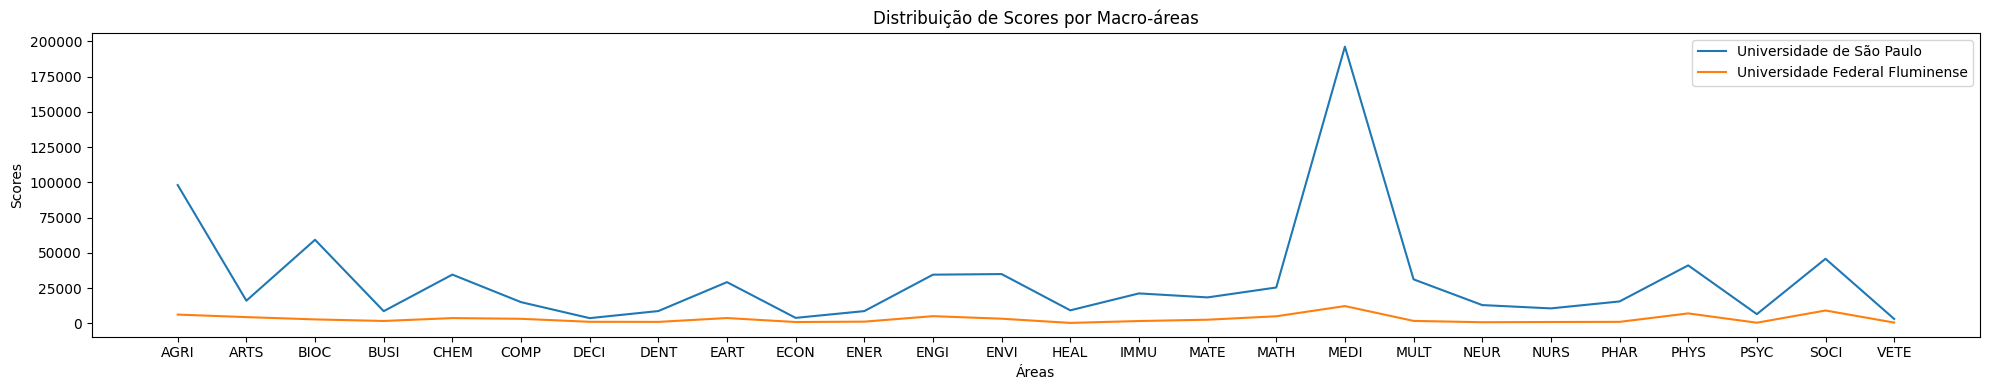

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_rows(df_comparativos_a.head(2), False, 'Macro')

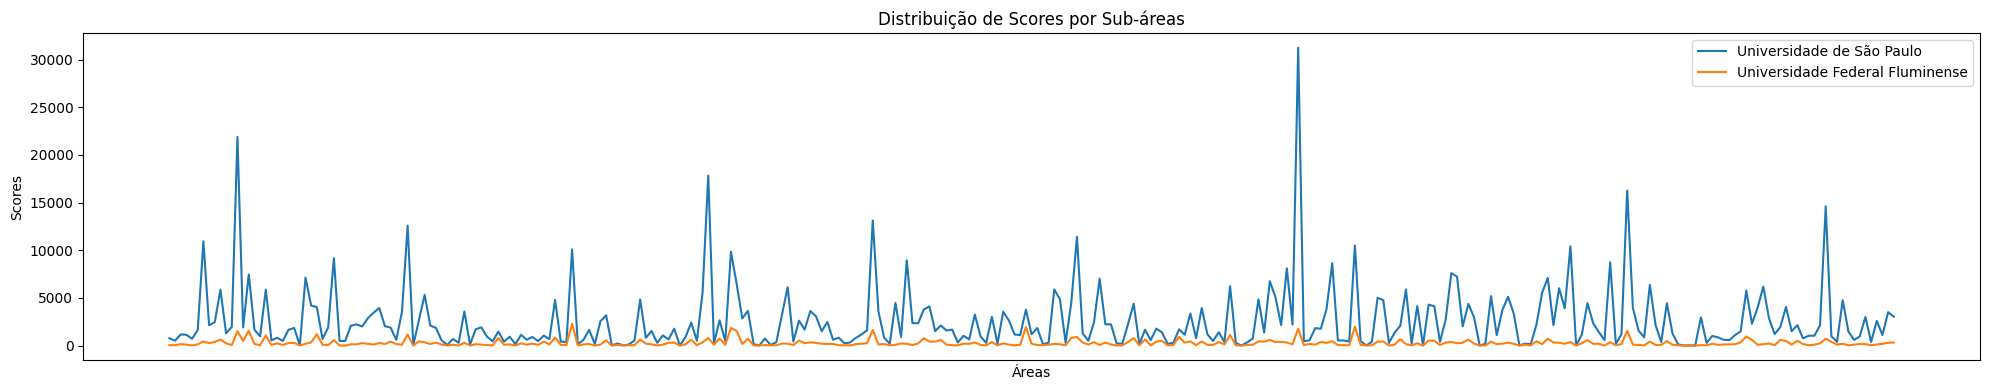

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_rows(df_comparativos_b.head(2), True, 'Sub')